##Importing Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Display Settings
pd.set_option('display.max_columns', None)

# Style for plots
sns.set_style('whitegrid')

##DataSet Loading

In [ ]:
# Load Forest Dataset
forest_file = "/content/drive/MyDrive/Bird species/Bird_Monitoring_Data_FOREST.XLSX"
forest = pd.read_excel(forest_file, sheet_name=None)

# Load Grassland Dataset
grassland_file = "/content/drive/MyDrive/Bird species/Bird_Monitoring_Data_GRASSLAND.XLSX"
grassland = pd.read_excel(grassland_file, sheet_name=None)

print("Forest Sheets:", len(forest))
print("Grassland Sheets:", len(grassland))

Forest Sheets: 11
Grassland Sheets: 11


##Merging Sheets

In [ ]:
forest_df = pd.concat(forest.values(), ignore_index=True)
grassland_df = pd.concat(grassland.values(), ignore_index=True)

print("Forest Shape:", forest_df.shape)
print("Grassland Shape:", grassland_df.shape)

Forest Shape: (8546, 29)
Grassland Shape: (8531, 29)


/tmp/ipykernel_1764/731006735.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grassland_df = pd.concat(grassland.values(), ignore_index=True)


##Habitat Labels

In [ ]:
forest_df["Habitat"] = "Forest"
grassland_df["Habitat"] = "Grassland"

bird_data = pd.concat([forest_df, grassland_df], ignore_index=True)

bird_data.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,ID_Method,Distance,Flyover_Observed,Sex,Common_Name,Scientific_Name,AcceptedTSN,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Singing,<= 50 Meters,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,179276.0,83803.0,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Calling,<= 50 Meters,False,NaN,White-breasted Nuthatch,Sitta carolinensis,178775.0,90935.0,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Calling,50 - 100 Meters,False,NaN,Red-bellied Woodpecker,Melanerpes carolinus,178195.0,84865.0,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Singing,<= 50 Meters,False,NaN,Orchard Oriole,Icterus spurius,179064.0,93634.0,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Visualization,<= 50 Meters,False,NaN,Northern Mockingbird,Mimus polyglottos,178620.0,88394.0,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN


##Dataset Overview

In [ ]:
bird_data.info()
bird_data.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    17077 non-null  object        
 4   Location_Type                17077 non-null  object        
 5   Year                         17077 non-null  object        
 6   Date                         17077 non-null  datetime64[ns]
 7   Start_Time                   17077 non-null  object        
 8   End_Time                     17077 non-null  object        
 9   Observer                     17077 non-null  object        
 10  Visit                        17077 non-null  object        
 11  Interval_Length              17077 non-nu

,0
Sub_Unit_Code,16355
TaxonCode,8548
Previously_Obs,8546
Site_Name,8531
NPSTaxonCode,8531
Sex,5183
Distance,1486
AcceptedTSN,33
ID_Method,2
Date,0


##Data  Cleaning

In [ ]:
# Remove duplicates
bird_data = bird_data.drop_duplicates()

# Standardize column names
bird_data.columns = bird_data.columns.str.strip()

print("Dataset Shape:", bird_data.shape)

Dataset Shape: (15372, 32)


In [ ]:
bird_data.describe()

,Date,AcceptedTSN,NPSTaxonCode,Temperature,Humidity,TaxonCode
count,15372,15344.000000,8546.000000,15372.000000,15372.000000,6824.000000
mean,2018-06-13 17:45:11.943794176,227017.842870,137088.791013,22.493826,74.159335,105706.437720
min,2018-05-07 00:00:00,174717.000000,76625.000000,11.000000,7.300000,76625.000000
25%,2018-05-24 00:00:00,178581.000000,85846.000000,19.700001,68.000000,84865.000000
50%,2018-06-14 00:00:00,179124.000000,88350.000000,22.200001,76.599998,88296.000000
75%,2018-07-03 00:00:00,179680.000000,94215.000000,25.000000,83.400002,94215.000000
max,2018-07-19 00:00:00,950106.000000,926917.000000,37.299999,98.800003,926917.000000
std,NaN,154014.872569,154932.276585,4.193138,12.168509,90324.364703


## Number of Bird Observations by Habitat

In [ ]:
bird_data['Habitat'].value_counts()

,count
Habitat,
Forest,8546
Grassland,6826


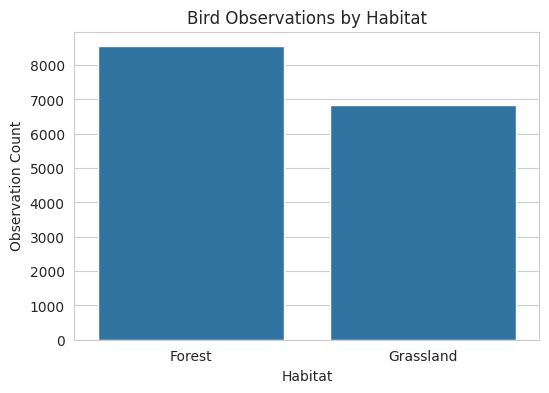

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Habitat',
    data=bird_data
)

plt.title('Bird Observations by Habitat')
plt.xlabel('Habitat')
plt.ylabel('Observation Count')

plt.show()

##SPECIES DIVERSITY ANALYSIS

In [ ]:
species_diversity = bird_data.groupby('Habitat')['Common_Name'].nunique()

print(species_diversity)

Habitat
Forest       108
Grassland    107
Name: Common_Name, dtype: int64


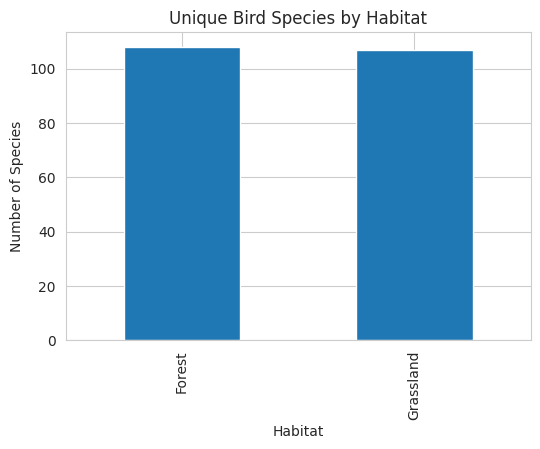

In [ ]:
species_diversity.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Unique Bird Species by Habitat')
plt.ylabel('Number of Species')

plt.show()

##TOP 10 MOST OBSERVED SPECIES

In [ ]:
top_species = bird_data['Common_Name'].value_counts().head(10)

print(top_species)

Common_Name
Northern Cardinal          1125
Carolina Wren               993
Red-eyed Vireo              738
Eastern Tufted Titmouse     720
Indigo Bunting              611
Eastern Wood-Pewee          574
Field Sparrow               492
Red-bellied Woodpecker      489
American Robin              470
Acadian Flycatcher          462
Name: count, dtype: int64


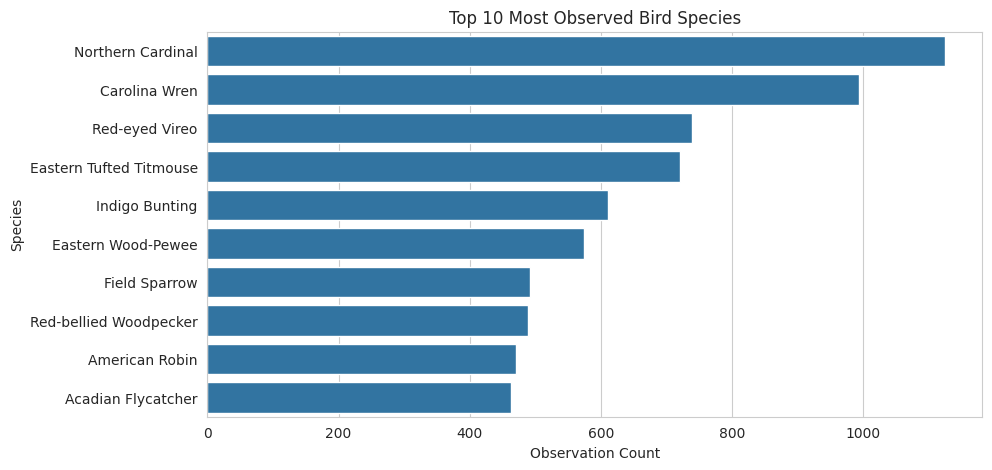

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_species.values,
    y=top_species.index
)

plt.title('Top 10 Most Observed Bird Species')
plt.xlabel('Observation Count')
plt.ylabel('Species')

plt.show()

##FOREST SPECIES ANALYSIS

In [ ]:
forest_species = (
    forest_df['Common_Name']
    .value_counts()
    .head(10)
)

forest_species

,count
Common_Name,
Red-eyed Vireo,694
Carolina Wren,646
Northern Cardinal,595
Eastern Tufted Titmouse,541
Eastern Wood-Pewee,486
Acadian Flycatcher,436
Red-bellied Woodpecker,398
Blue-gray Gnatcatcher,310
Ovenbird,303


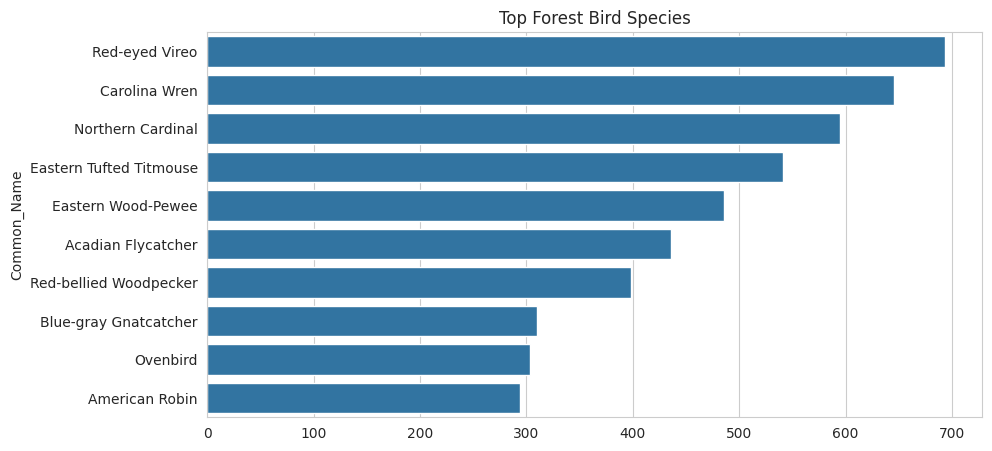

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=forest_species.values,
    y=forest_species.index
)

plt.title('Top Forest Bird Species')

plt.show()

##GRASSLAND SPECIES ANALYSIS

In [ ]:
grass_species = (
    grassland_df['Common_Name']
    .value_counts()
    .head(10)
)

grass_species

,count
Common_Name,
Northern Cardinal,565
European Starling,516
Field Sparrow,506
Indigo Bunting,485
Grasshopper Sparrow,382
Red-winged Blackbird,379
Chipping Sparrow,368
Carolina Wren,365
American Goldfinch,362


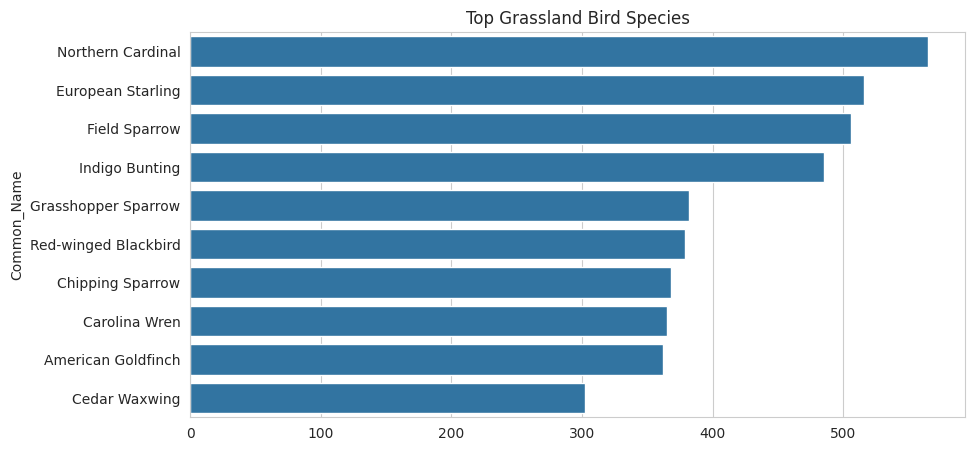

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=grass_species.values,
    y=grass_species.index
)

plt.title('Top Grassland Bird Species')

plt.show()

##ENVIRONMENTAL CONDITIONS

In [ ]:
bird_data.groupby('Habitat')['Temperature'].mean()

,Temperature
Habitat,
Forest,21.871507
Grassland,23.272956


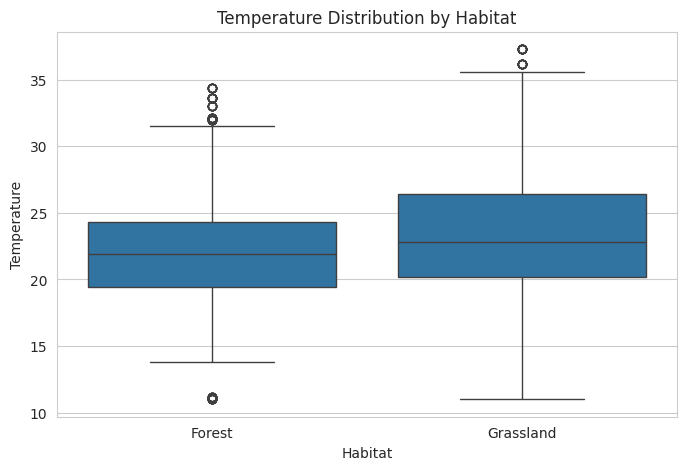

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Habitat',
    y='Temperature',
    data=bird_data
)

plt.title('Temperature Distribution by Habitat')

plt.show()

##HUMIDITY ANALYSIS

In [ ]:
bird_data.groupby('Habitat')['Humidity'].mean()

,Humidity
Habitat,
Forest,77.757032
Grassland,69.655098


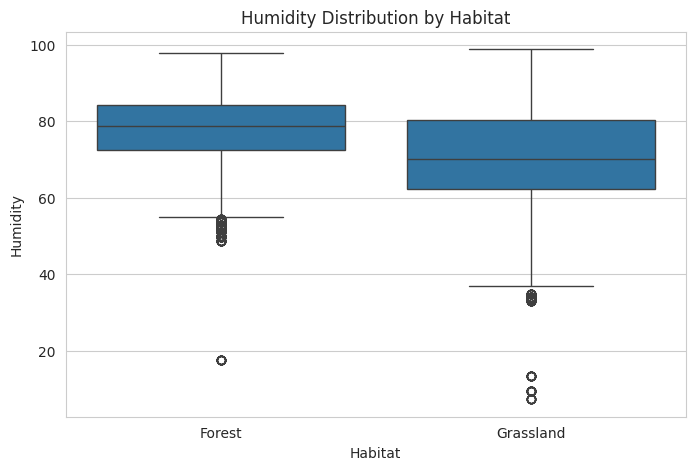

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Habitat',
    y='Humidity',
    data=bird_data
)

plt.title('Humidity Distribution by Habitat')

plt.show()

##CONVERSION PRIORITY SPECIES

In [ ]:
watchlist_species = bird_data[
    bird_data['PIF_Watchlist_Status'].notna()
]

watchlist_species.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,ID_Method,Distance,Flyover_Observed,Sex,Common_Name,Scientific_Name,AcceptedTSN,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Singing,<= 50 Meters,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,179276.0,83803.0,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Calling,<= 50 Meters,False,NaN,White-breasted Nuthatch,Sitta carolinensis,178775.0,90935.0,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Calling,50 - 100 Meters,False,NaN,Red-bellied Woodpecker,Melanerpes carolinus,178195.0,84865.0,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Singing,<= 50 Meters,False,NaN,Orchard Oriole,Icterus spurius,179064.0,93634.0,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Visualization,<= 50 Meters,False,NaN,Northern Mockingbird,Mimus polyglottos,178620.0,88394.0,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,NaN,NaN


In [ ]:
watchlist_counts = (
    watchlist_species.groupby('Habitat')
    .size()
)

watchlist_counts

,0
Habitat,
Forest,8546
Grassland,6826


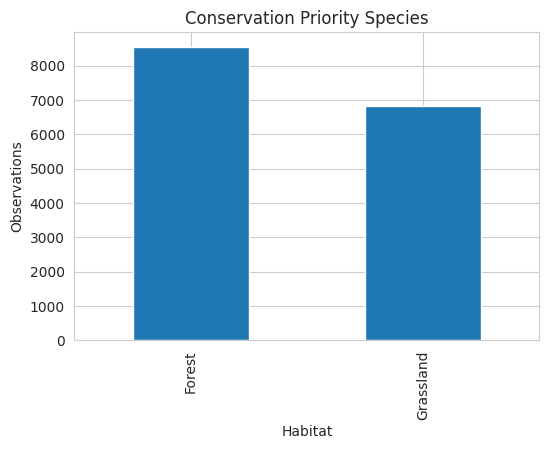

In [ ]:
watchlist_counts.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Conservation Priority Species')

plt.ylabel('Observations')

plt.show()

##SPECIES OVERLAP BETWEEN HABITATS

In [ ]:
forest_set = set(forest_df['Common_Name'].dropna())
grass_set = set(grassland_df['Common_Name'].dropna())

common_species = forest_set.intersection(grass_set)

forest_only = forest_set - grass_set

grass_only = grass_set - forest_set

print("Common Species:", len(common_species))
print("Forest Only:", len(forest_only))
print("Grassland Only:", len(grass_only))

Common Species: 89
Forest Only: 19
Grassland Only: 18


##Administrative Unit Analysis

In [ ]:
unit_counts = (
    bird_data['Admin_Unit_Code']
    .value_counts()
)

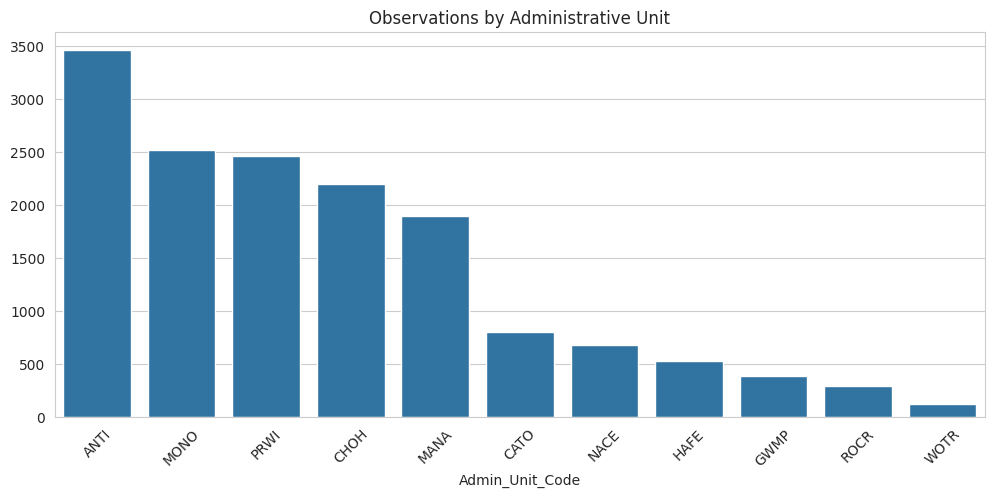

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=unit_counts.index,
    y=unit_counts.values
)

plt.title('Observations by Administrative Unit')

plt.xticks(rotation=45)

plt.show()

##CORRELATION ANALYSIS

In [ ]:
numerical_cols = ['Temperature', 'Humidity']

corr = bird_data[numerical_cols].corr()

corr

,Temperature,Humidity
Temperature,1.000000,-0.337616
Humidity,-0.337616,1.000000


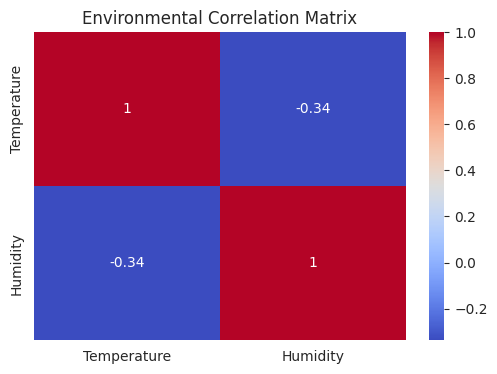

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Environmental Correlation Matrix')

plt.show()

##KEY INSIGHTS

In [ ]:
print("Forest Species Diversity:", forest_df['Common_Name'].nunique())

print("Grassland Species Diversity:", grassland_df['Common_Name'].nunique())

print("Total Species:",
      bird_data['Common_Name'].nunique())

Forest Species Diversity: 108
Grassland Species Diversity: 107
Total Species: 126


##CONCLUSION

Conclusion

1. Forest habitats exhibit slightly greater species diversity.
2. Most bird species occur in both habitats.
3. Forest ecosystems contain more conservation-priority species.
4. Temperature and humidity differ substantially between habitats.
5. Both ecosystems are essential for maintaining regional biodiversity.

These findings support habitat-specific conservation and biodiversity management strategies.